## Study case

Student mental health has become a growing concern worldwide. Family environment is believed to be one of the key factors influencing students' emotional well-being.

In this project, we analyze the *Student Depression Dataset* to investigate whether there is a significant difference in depression rates between students **with** and **without** a family history of mental illness. The goal is to generate insights that can help educational institutions provide better mental health support for students.

In [1]:
# load data
import pandas as pd
import numpy as np

### 1. Exploratory Data Analysis

The first step is to understand the dataset to be used:
- Review the structure and content of the dataset
- Check the number of samples in each group (whether or not there is a family history)
- Check for missing values ​​and handle them if any
- Check for duplicate data and handle them if any

In [2]:
csv_path = 'Student Depression Dataset.csv'
df_case = pd.read_csv(csv_path, delimiter=',')
df_case.head()

,id,Gender,City,Family History of Mental Illness,Depression
0,2,Male,Visakhapatnam,No,1
1,8,Female,Bangalore,Yes,0
2,26,Male,Srinagar,Yes,0
3,30,Female,Varanasi,Yes,1
4,32,Female,Jaipur,No,0


In [3]:
df_case.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id                                5000 non-null   int64 
 1   Gender                            5000 non-null   object
 2   City                              5000 non-null   object
 3   Family History of Mental Illness  5000 non-null   object
 4   Depression                        5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


In [4]:
df_case['id'].nunique()

5000

Sample distribution based on family mental health history:
- **'Yes' group** = students with a family history
- **'No' group** = students without a family history

In [5]:
df_case['Family History of Mental Illness'].value_counts()

Family History of Mental Illness
No     2583
Yes    2417
Name: count, dtype: int64

In [6]:
pd.crosstab(df_case['Family History of Mental Illness'], df_case['Depression'])

Depression,0,1
Family History of Mental Illness,,
No,1116,1467
Yes,944,1473


Missing Values ​​and Duplicate Check:
- Do any of the rows have missing values?
- Then, we need to look for the duplicate data. If there is duplicate data, we need to drop it out.

In [7]:
df_case.isnull().sum()

id                                  0
Gender                              0
City                                0
Family History of Mental Illness    0
Depression                          0
dtype: int64

In [8]:
df_case['id'].duplicated().sum()

np.int64(0)

### 2. Define Hypothesis

- What to prove: Is there a significant difference in the proportion of depression between students who have a family history of mental health and those who do not?
- Since we want to know if there is a **difference** (without specifying direction), this is a **two-tailed test**.
- $H_0$ (Null Hypothesis). There was no difference in the proportion of depression between students with and without a family history of mental health.
   $$H_0:P_1 = P_2$$
- Alternative hypothesis ($H_1$) is the opposite claim from null hypothesis
 - $H_1$: There was a difference in the proportion of depression between the two groups.
    $$H_1:P_1 \ne P_2$$
    
- Set Siginificance Level (alpha) = 0.05

In [9]:
no_people_depression = (df_case['Family History of Mental Illness'] == 'No') & (df_case['Depression'] == 1)
yes_people_depression = (df_case['Family History of Mental Illness'] == 'Yes') & (df_case['Depression'] == 1)

In [10]:
no_people_depression = df_case[no_people_depression]
yes_people_depression = df_case[yes_people_depression]

In [11]:
no_depression = len(no_people_depression)
yes_depression = len(yes_people_depression)

In [12]:
n_depr = len(df_case[df_case['Family History of Mental Illness'] == 'No'])
y_depr = len(df_case[df_case['Family History of Mental Illness'] == 'Yes'])

### 3. Statistical Test

We used the Two-Sample Z-Test for Proportions with `statsmodels` to compare the proportion of depression between two independent groups.

In [13]:
from statsmodels.stats.proportion import proportions_ztest

After calculating the Z-statistic, we find the critical z-value for comparison. Since the two-tailed test has alpha = 0.05, the critical value is **z = ±1.96**.

In [14]:
test_stat, p_value = proportions_ztest(count=[yes_depression, no_depression],
                                       nobs = [y_depr, n_depr],
                                       alternative='two-sided')

print("The computed Z test statistic is: ",np.round(test_stat, 4))
print("The p-value is: ", np.round(p_value,4))

The computed Z test statistic is:  2.9786
The p-value is:  0.0029


### 4. Critical Value and Decision Rule

For a two-tailed test with alpha = 0.05, the critical z-value is **±1.96**.

In [15]:
# critical value in our case is z-value where the left-tailed area under a standard normal distribution is 0.05 (alpha)
import scipy.stats as stats
z_crit = stats.norm.ppf(1-0.05/2)
print(z_crit)

1.959963984540054


In [16]:
# Decision rule
if p_value<0.05:
    print("Reject the null hypothesis")
else:
    print("Failed to reject the Null hypothesis")

Reject the null hypothesis


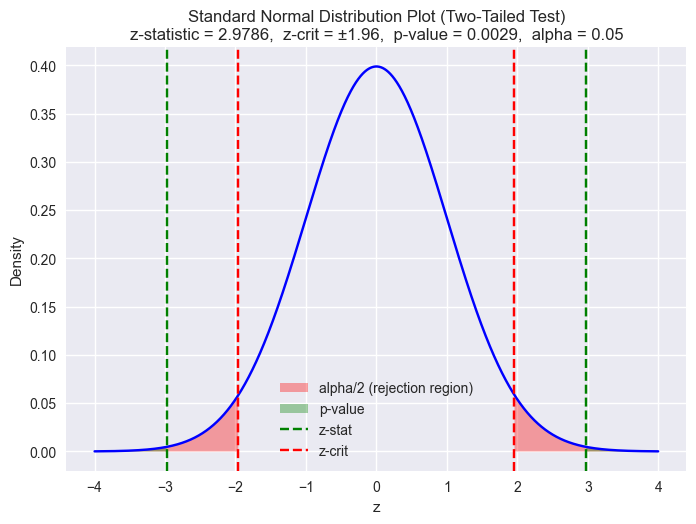

In [17]:
# Visualisasi distribusi normal
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Plot distribusi normal standar
x = np.arange(-4, 4, 0.001)
plt.plot(x, stats.norm.pdf(x, 0, 1), color='blue')

# Daerah penolakan alpha (two sided)
x_alpha_right = np.arange(z_crit, 4, 0.01)
x_alpha_left  = np.arange(-4, -z_crit, 0.01)
plt.fill_between(x=x_alpha_right, y1=stats.norm.pdf(x_alpha_right),
                 facecolor='red', alpha=0.35, label='alpha/2 (rejection region)')
plt.fill_between(x=x_alpha_left,  y1=stats.norm.pdf(x_alpha_left),
                 facecolor='red', alpha=0.35)

# Daerah p-value (two sided)
x_pvalue_right = np.arange(abs(test_stat), 4, 0.01)
x_pvalue_left  = np.arange(-4, -abs(test_stat), 0.01)
plt.fill_between(x=x_pvalue_right, y1=stats.norm.pdf(x_pvalue_right),
                 facecolor='green', alpha=0.35, label='p-value')
plt.fill_between(x=x_pvalue_left,  y1=stats.norm.pdf(x_pvalue_left),
                 facecolor='green', alpha=0.35)

# z-stat dan z-crit vertical line
plt.axvline( np.round(test_stat, 4), color='green', linestyle='--', label='z-stat')
plt.axvline(-np.round(test_stat, 4), color='green', linestyle='--')
plt.axvline( z_crit, color='red', linestyle='--', label='z-crit')
plt.axvline(-z_crit, color='red', linestyle='--')

plt.legend()
plt.xlabel('z')
plt.ylabel('Density')
plt.title(
    f'Standard Normal Distribution Plot (Two-Tailed Test)\n'
    f'z-statistic = {np.round(test_stat, 4)},  '
    f'z-crit = ±{np.round(z_crit, 4)},  '
    f'p-value = {np.round(p_value, 4)},  '
    f'alpha = 0.05'
)
plt.show()

Based on the statistical test results:
- Z-statistic = **2.9786**, exceeding the critical value of **±1.96**
- P-value = **0.0029** < alpha = **0.05**

Therefore, we **reject $H_0$**.

### 5. Confidence Interval

After knowing the results of the hypothesis test, we calculate a 95% confidence interval to estimate the difference in the proportion of depression between the two groups at the population level.

In [18]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import confint_proportions_2indep

confidence_interval = confint_proportions_2indep(count1 = yes_depression, nobs1 = y_depr,
                                                 count2 = no_depression, nobs2 = n_depr, 
                                                 compare='diff', alpha=0.05)
print(confidence_interval)

(np.float64(0.014192836116198128), np.float64(0.06867865502674123))


### 6. Conclusion

Statistical test results (Two-Sample Z-Test for Proportions):**
- Z-statistic = **2.9786** > Z-critical = **±1.96**
- P-value = **0.0029** < Alpha = **0.05**

**Decision: Reject $H_0$**

Because the p-value (0.0029) is less than alpha (0.05), we **reject the null hypothesis**. There is sufficient statistical evidence to conclude that:

> **There is a significant difference between the proportion of depression in students with a family history of mental health (60.94%) and those without (56.79%).**

**Confidence Interval:**
- The difference in the proportion of depression (P1 − P_2) is in the range of **1.42% to 6.88%** (with a 95% confidence level).

- Because all intervals are positive and do not include 0, this strengthens the conclusion that the difference is statistically significant.

**Recommendations:**
- Educational institutions should pay special attention to students with a family history of mental health issues.
- Psychological screening and support programs can be prioritized for this high-risk group to prevent or treat depression early.